# Arkansas Environmental Risk Screening
## Final Project — GIS Programming | Western Michigan University

---

### Project Overview

Communities throughout Arkansas are exposed to a range of ecological threats, including air pollution, 
built-up land intensity, and population concentration in vulnerable areas. This project develops a 
**tract-level environmental risk screening model** for Arkansas using three indicator variables:

1. **Population density** — from the 2022 American Community Survey (ACS), US Census
2. **GHSL built-up intensity** — from Google Earth Engine (Global Human Settlement Layer)
3. **Tract-level PM2.5** — ambient particulate matter air pollution exposure

The goal is to identify census tracts where these factors overlap and generate a relative environmental 
screening score, supporting environmental justice analysis at the state level.

---

### Table of Contents

1. [Initial Plan & Problem Statement](#section1)
2. [Data Sources & Conceptual Analysis](#section2)
3. [Environment Setup](#section3)
4. [Population Base Layer — ACS Census](#section4)
5. [Earth Engine Integration — GHSL](#section5)
6. [Air Quality Layer — PM2.5](#section6)
7. [Risk Score Construction](#section7)
8. [Population Summary & County Analysis](#section8)
9. [Maps & Data Visualization](#section9)
10. [Discussion & Limitations](#section10)
11. [Conclusion & Next Steps](#section11)
12. [Export Outputs](#section12)


---
<a id="section1"></a>

## 1. Initial Plan & Problem Statement

### Problem Statement

Arkansas has 75 counties and over 700 census tracts with varying levels of exposure to environmental burdens. 
State and regional agencies need a repeatable, data-driven framework to identify which tracts experience the greatest 
overlap of environmental pressures and population vulnerability.

This project addresses that need by building a **three-variable screening score** combining population density, 
built-up intensity, and ambient air pollution (PM2.5) at the census tract level.

### Level of Effort (LOE)

| Task |
|------|
| Data discovery and download | 
| Data cleaning and GEOID alignment | 
| GEE export and integration | 
| Analysis and scoring | 
| Mapping and visualization | 
| Notebook cleanup and documentation | 


### Budget

All datasets are publicly available at no cost (US Census, Google Earth Engine, EPA). 



---
<a id="section2"></a>

## 2. Data Sources & Conceptual Analysis

### Datasets Used

| Dataset | Source | Geography | Purpose |
|---------|--------|-----------|---------|
| ACS 2022 5-Year Estimates | US Census Bureau | Census Tract | Population base layer |
| GHSL 2020 (Built-up Surface) | Google Earth Engine | ~10m raster aggregated to tract | Built environment indicator |
| PM2.5 Tract-Level Concentrations | EPA / CDC PLACES | Census Tract | Air quality indicator |

### Conceptual Analysis

The three variables capture different dimensions of environmental burden and population vulnerability:

- **Population density** is a proxy for the number of people potentially exposed. High-density tracts concentrate exposure risk.
- **GHSL built-up intensity** captures the degree of human settlement and impervious surface, linked to urban heat islands, stormwater runoff, and reduced green space.
- **PM2.5** is one of the most well-documented environmental health risk indicators. Fine particulate matter is associated with respiratory and cardiovascular disease, and disproportionately affects low-income and minority communities.

Together, these three variables form the basis for a **relative screening index** — not an absolute health-risk model, 
but a spatial tool for identifying where multiple burdens overlap.

### Why Google Earth Engine (GEE)?

GHSL data was accessed and summarized using Google Earth Engine, satisfying the requirement of at least one GEE layer. 
The GHSL built-up surface layer provides globally consistent, satellite-derived settlement data at finer resolution than most administrative datasets.


---
<a id="section3"></a>

## 3. Environment Setup

The following libraries are required. Install via `pip install geopandas pandas numpy matplotlib`.

- `geopandas` — spatial data operations and GeoDataFrame handling
- `pandas` / `numpy` — tabular data manipulation and numerical operations
- `matplotlib` — map and chart visualization


In [12]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# -------------------------------
# File paths (update if needed)
# -------------------------------
gdb_path = r"D:\WesternMichiganUni\GIS_Programming\FinalProject\ACS_2022_5YR_TRACT_05.gdb\ACS_2022_5YR_TRACT_05_ARKANSAS.gdb"
ghsl_csv = r"D:\WesternMichiganUni\GIS_Programming\FinalProject\Arkansas_Tract_GHSL_Stats_2020.csv"
pm25_path = r"D:\WesternMichiganUni\GIS_Programming\FinalProject\PM2.5_AR\data_144231.csv"
output_folder = r"D:\WesternMichiganUni\GIS_Programming\FinalProject\output"
os.makedirs(output_folder, exist_ok=True)

print("GDB exists:", os.path.exists(gdb_path))
print("GHSL CSV exists:", os.path.exists(ghsl_csv))
print("PM2.5 CSV exists:", os.path.exists(pm25_path))
print("Output folder:", output_folder)


GDB exists: True
GHSL CSV exists: True
PM2.5 CSV exists: True
Output folder: D:\WesternMichiganUni\GIS_Programming\FinalProject\output


---
<a id="section4"></a>

## 4. Population Base Layer — ACS Census Tracts

### Data Description

The **American Community Survey (ACS) 2022 5-Year Estimates** geodatabase contains Arkansas census tract boundaries 
and demographic attribute tables. The table `X01_AGE_AND_SEX` contains total population (`B01003_E001`) for each tract.

### Step 4a — Load tract geometry and population table


In [13]:

tracts = gpd.read_file(gdb_path, layer="ACS_2022_5YR_TRACT_05_ARKANSAS")
age_sex = gpd.read_file(gdb_path, layer="X01_AGE_AND_SEX")

print("Tracts shape:", tracts.shape)
print("Age/Sex shape:", age_sex.shape)


Tracts shape: (823, 16)
Age/Sex shape: (823, 719)


### Step 4b — Build 11-digit GEOID and join population

**Problem:** The ACS geodatabase uses a fully-qualified identifier (`GEOIDFQ`) rather than the standard 11-digit GEOID 
used by other datasets.  
**Solution:** Extract the last 11 characters of `GEOIDFQ` to create a consistent join key across all datasets.


In [14]:

# Build clean 11-digit tract GEOID and join total population
tracts_geom = tracts[["GEOIDFQ", "geometry"]].copy()
tracts_geom["GEOID"] = tracts_geom["GEOIDFQ"].astype(str).str[-11:]
tracts_geom = tracts_geom[["GEOID", "geometry"]]

pop_table = age_sex[["GEOIDFQ", "B01003_E001"]].copy()
pop_table["GEOID"] = pop_table["GEOIDFQ"].astype(str).str[-11:]
pop_table = pop_table.rename(columns={"B01003_E001": "total_pop"})
pop_table["total_pop"] = pd.to_numeric(pop_table["total_pop"], errors="coerce").fillna(0)
pop_table = pop_table[["GEOID", "total_pop"]]

tracts_final = tracts_geom.merge(pop_table, on="GEOID", how="left")
print(tracts_final.head())


         GEOID                                           geometry  total_pop
0  05067480402  MULTIPOLYGON (((-91.2356 35.6658, -91.23558 35...     2704.0
1  05067480401  MULTIPOLYGON (((-91.37393 35.48766, -91.37334 ...     1470.0
2  05051010501  MULTIPOLYGON (((-92.9865 34.47365, -92.98647 3...     4570.0
3  05051011902  MULTIPOLYGON (((-93.11503 34.39164, -93.11487 ...     2543.0
4  05051011101  MULTIPOLYGON (((-93.40717 34.39861, -93.40711 ...     5363.0


### Step 4c — Calculate tract area and population density

The tract layer is reprojected to **EPSG:5070** (USA Contiguous Albers Equal Area Conic) to accurately compute area in square kilometers. 
Population density is derived as persons per km².


In [15]:

tracts_final = tracts_final.to_crs("EPSG:5070")
tracts_final["area_km2"] = tracts_final.geometry.area / 1e6
tracts_final["pop_density"] = np.where(
    tracts_final["area_km2"] > 0,
    tracts_final["total_pop"] / tracts_final["area_km2"],
    np.nan
)

print(tracts_final[["GEOID", "total_pop", "area_km2", "pop_density"]].head())


         GEOID  total_pop    area_km2  pop_density
0  05067480402     2704.0  219.087018    12.342128
1  05067480401     1470.0  605.851671     2.426336
2  05051010501     4570.0  101.033463    45.232538
3  05051011902     2543.0   63.611177    39.977251
4  05051011101     5363.0  157.547444    34.040539


---
<a id="section5"></a>

## 5. Earth Engine Integration — GHSL Built-up Intensity

### Data Description

The **Global Human Settlement Layer (GHSL)** is a Copernicus-funded dataset available in Google Earth Engine. 
The built-up surface layer (`GHS_BUILT_S`) quantifies built-up area fraction and intensity at ~10m resolution (2020 epoch).

### GEE Export Workflow

The GHSL raster was summarized at the census tract level using a Google Earth Engine script that:

1. Loaded the GHSL Built-up Surface raster for 2020
2. Loaded Arkansas census tract boundaries as a FeatureCollection
3. Applied `reduceRegions()` with `mean` and `sum` reducers to compute per-tract statistics
4. Exported results as `Arkansas_Tract_GHSL_Stats_2020.csv`

### Step 5a — Load and merge GHSL tract statistics


In [16]:

ghsl = pd.read_csv(ghsl_csv)
ghsl["GEOID"] = ghsl["GEOID"].astype(str).str.zfill(11)

ghsl_keep = ghsl[[
    "GEOID",
    "ghsl_built_mean",
    "ghsl_built_sum",
    "ghsl_pop_density",
    "ghsl_pop_sum"
]].copy()

tracts_final["GEOID"] = tracts_final["GEOID"].astype(str).str.zfill(11)
tracts_final = tracts_final.merge(ghsl_keep, on="GEOID", how="left")

print(tracts_final[[
    "GEOID", "total_pop", "pop_density",
    "ghsl_built_mean", "ghsl_built_sum",
    "ghsl_pop_density", "ghsl_pop_sum"
]].head())


         GEOID  total_pop  pop_density  ghsl_built_mean  ghsl_built_sum  \
0  05067480402     2704.0    12.342128        24.385520    5.353985e+05   
1  05067480401     1470.0     2.426336        12.276790    7.454090e+05   
2  05051010501     4570.0    45.232538       121.586655    1.231224e+06   
3  05051011902     2543.0    39.977251       128.276419    8.179161e+05   
4  05051011101     5363.0    34.040539        98.494257    1.555472e+06   

   ghsl_pop_density  ghsl_pop_sum  
0         12.394400   2715.252274  
1          3.155583   1911.746221  
2         39.459503   3987.443006  
3         35.184105   2238.550757  
4         31.877756   5023.245379  


### Step 5b — Quality check on GHSL merge

Verify that the GHSL statistics joined correctly and identify any missing values before proceeding.


In [17]:

print("Missing ghsl_built_mean:", tracts_final["ghsl_built_mean"].isna().sum())
print("Missing ghsl_pop_density:", tracts_final["ghsl_pop_density"].isna().sum())


Missing ghsl_built_mean: 0
Missing ghsl_pop_density: 0


---
<a id="section6"></a>

## 6. Air Quality Layer — PM2.5

### Data Description

Tract-level ambient PM2.5 concentrations are sourced from the EPA/CDC PLACES dataset. 
PM2.5 (fine particulate matter ≤ 2.5 micrometers) is the most widely used indicator of air quality-related health risk, 
with well-established links to respiratory and cardiovascular disease.

### Challenge

Several candidate PM2.5 files obtained earlier were monitor-based or county-level rather than census-tract level. 
Monitor data requires spatial interpolation, which was outside the scope of this project.  
**Solution:** A tract-level PM2.5 CSV was identified containing daily values per tract GEOID, which are aggregated to an annual mean per tract before joining.

### Step 6a — Load PM2.5 data


In [18]:

pm25 = pd.read_csv(pm25_path, encoding="latin1")
print(pm25.columns.tolist())
print(pm25.head())


['StateFIPS', 'State', 'CensusTract', 'Census Tract', 'Year', 'Date', 'Value', 'Data Comment', 'AQI Category', 'Concentration (µg/m³)', 'Unnamed: 10', 'Data Source']
   StateFIPS     State  CensusTract                       Census Tract  Year  \
0          5  Arkansas   5001480100  Arkansas County, AR - 05001480100  2026   
1          5  Arkansas   5001480100  Arkansas County, AR - 05001480100  2026   
2          5  Arkansas   5001480100  Arkansas County, AR - 05001480100  2026   
3          5  Arkansas   5001480100  Arkansas County, AR - 05001480100  2026   
4          5  Arkansas   5001480100  Arkansas County, AR - 05001480100  2026   

         Date Value  Data Comment  AQI Category Concentration (µg/m³)  \
0  2026-01-01   2.0           NaN  Moderate (2)                  12.6   
1  2026-01-03   2.0           NaN  Moderate (2)                  17.3   
2  2026-03-02   2.0           NaN  Moderate (2)                  15.0   
3  2026-03-05   1.0           NaN      Good (1)              

### Step 6b — Aggregate to tract mean and merge

Daily records are collapsed to a single mean PM2.5 value per tract GEOID. 
A safe merge removes any pre-existing PM2.5 column to prevent duplicate columns from repeated notebook runs.


In [19]:

pm25["GEOID"] = pm25["CensusTract"].astype(str).str.zfill(11)
pm25["Value"] = pd.to_numeric(pm25["Value"], errors="coerce")

pm25_tract = (
    pm25.groupby("GEOID", dropna=False)["Value"]
    .mean()
    .reset_index()
    .rename(columns={"Value": "pm25_2026_mean"})
)

# Safe merge: remove any previous raw PM2.5 column if it exists
cols_to_drop = [c for c in tracts_final.columns if c == "pm25_2026_mean" or c.startswith("pm25_2026_mean_")]
if cols_to_drop:
    tracts_final = tracts_final.drop(columns=cols_to_drop)

tracts_final = tracts_final.merge(pm25_tract, on="GEOID", how="left")

print(tracts_final[["GEOID", "pm25_2026_mean"]].head())
print("Missing PM2.5:", tracts_final["pm25_2026_mean"].isna().sum())


         GEOID  pm25_2026_mean
0  05067480402        1.523077
1  05067480401        1.538462
2  05051010501        1.492308
3  05051011902        1.492308
4  05051011101        1.492308
Missing PM2.5: 47


---
<a id="section7"></a>

## 7. Risk Score Construction

### Methodology

The three indicator variables are measured in different units:

- Population density: persons/km²
- GHSL built-up mean: dimensionless intensity (0–1 scale)
- PM2.5: micrograms per cubic meter (µg/m³)

To combine them, each variable is **min-max normalized** to a 0–1 scale. 
The final screening score is the **equal-weighted mean** of the three standardized values:

$$\text{Risk Score} = \frac{\text{PopDen}_{std} + \text{GHSL}_{std} + \text{PM2.5}_{std}}{3}$$

Tracts are then classified into 5 quintile-based risk classes: `Very Low`, `Low`, `Moderate`, `High`, `Very High`.

### Step 7 — Normalize variables and compute composite screening score


In [20]:

def minmax(series):
    s = pd.to_numeric(series, errors="coerce")
    smin = s.min(skipna=True)
    smax = s.max(skipna=True)
    if pd.isna(smin) or pd.isna(smax) or smax == smin:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - smin) / (smax - smin)

tracts_final["popden_std"] = minmax(tracts_final["pop_density"])
tracts_final["built_std"] = minmax(tracts_final["ghsl_built_mean"])
tracts_final["pm25_std"] = minmax(tracts_final["pm25_2026_mean"])

tracts_final["risk_score_3var"] = tracts_final[[
    "popden_std", "built_std", "pm25_std"
]].mean(axis=1)

risk_order = ["Very Low", "Low", "Moderate", "High", "Very High"]
tracts_final["risk_class_3var"] = pd.qcut(
    tracts_final["risk_score_3var"],
    q=5,
    labels=risk_order,
    duplicates="drop"
)

print(tracts_final[[
    "GEOID", "popden_std", "built_std", "pm25_std",
    "risk_score_3var", "risk_class_3var"
]].head())


         GEOID  popden_std  built_std  pm25_std  risk_score_3var  \
0  05067480402    0.002725   0.005719  0.842105         0.283516   
1  05067480401    0.000536   0.002073  0.894737         0.299115   
2  05051010501    0.009988   0.034982  0.736842         0.260604   
3  05051011902    0.008827   0.036996  0.736842         0.260889   
4  05051011101    0.007517   0.028030  0.736842         0.257463   

  risk_class_3var  
0        Moderate  
1        Moderate  
2             Low  
3             Low  
4             Low  


---
<a id="section8"></a>

## 8. Population Summary & County Aggregation

This section quantifies how much of the Arkansas population lives in elevated-risk tracts, 
and summarizes results at the county level for broader reporting and interpretation.


In [21]:

high_risk = tracts_final[tracts_final["risk_class_3var"].isin(["High", "Very High"])]

total_population = tracts_final["total_pop"].sum()
high_risk_population = high_risk["total_pop"].sum()
high_risk_pct = (high_risk_population / total_population) * 100 if total_population > 0 else np.nan

print(f"Total Arkansas population: {total_population:,.0f}")
print(f"Population in High + Very High tracts: {high_risk_population:,.0f}")
print(f"Percent of population in High + Very High tracts: {high_risk_pct:.2f}%")

tracts_final["county_fips"] = tracts_final["GEOID"].str[:5]

county_summary = (
    tracts_final.groupby("county_fips", dropna=False)
    .agg(
        total_pop=("total_pop", "sum"),
        mean_pop_density=("pop_density", "mean"),
        mean_built=("ghsl_built_mean", "mean"),
        mean_pm25=("pm25_2026_mean", "mean"),
        mean_risk_3var=("risk_score_3var", "mean")
    )
    .reset_index()
)

county_summary.head()


Total Arkansas population: 3,018,669
Population in High + Very High tracts: 1,280,977
Percent of population in High + Very High tracts: 42.44%


,county_fips,total_pop,mean_pop_density,mean_built,mean_pm25,mean_risk_3var
0,05001,17024.0,48.947126,166.891154,1.505769,0.280775
1,05003,19018.0,31.468396,91.006853,1.446154,0.043903
2,05005,41801.0,90.670344,300.005280,NaN,0.054359
3,05007,286528.0,455.948176,761.679799,1.412416,0.263965
4,05009,37662.0,130.303995,387.528430,1.426374,0.218366


---
<a id="section9"></a>

## 9. Maps & Data Visualization

This section produces **5 choropleth maps** and **4 analytical charts** to communicate 
the spatial distribution of each indicator and the composite screening score.

**Color palette rationale:**
- Population density → `YlGnBu` (yellow–green–blue perceptual ramp)
- GHSL built-up → `copper_r` (warm brown tones for built environment)
- PM2.5 → `RdPu` (white to red-purple; intuitive danger gradient)
- Risk score → `RdYlGn_r` (green = low risk, red = high risk)
- Risk classes → custom 5-color diverging palette


### Step 9a — Map helper function & color palette


In [22]:
from matplotlib.colors import ListedColormap

def make_map(gdf, column, title, cmap='viridis', categorical=False, legend=True):
    """Plot a single choropleth map for a GeoDataFrame column."""
    fig, ax = plt.subplots(figsize=(10, 8))
    gdf.plot(
        column=column,
        ax=ax,
        legend=legend,
        cmap=cmap,
        categorical=categorical,
        linewidth=0.05,
        edgecolor='white',
        missing_kwds={'color': '#d9d9d9', 'label': 'No data'}
    )
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

# 5-class diverging palette for risk classes
# Very Low=teal, Low=light blue, Moderate=yellow, High=orange, Very High=crimson
risk_cmap = ListedColormap(['#1a9850', '#91cf60', '#ffffbf', '#fc8d59', '#d73027'])
risk_order = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']

print('Map helper and color palette ready.')

Map helper and color palette ready.


### Map 1 — Population Density

ACS 2022 5-year tract-level population density (persons/km²). 
Darker purples indicate higher density; rural tracts dominate the state.


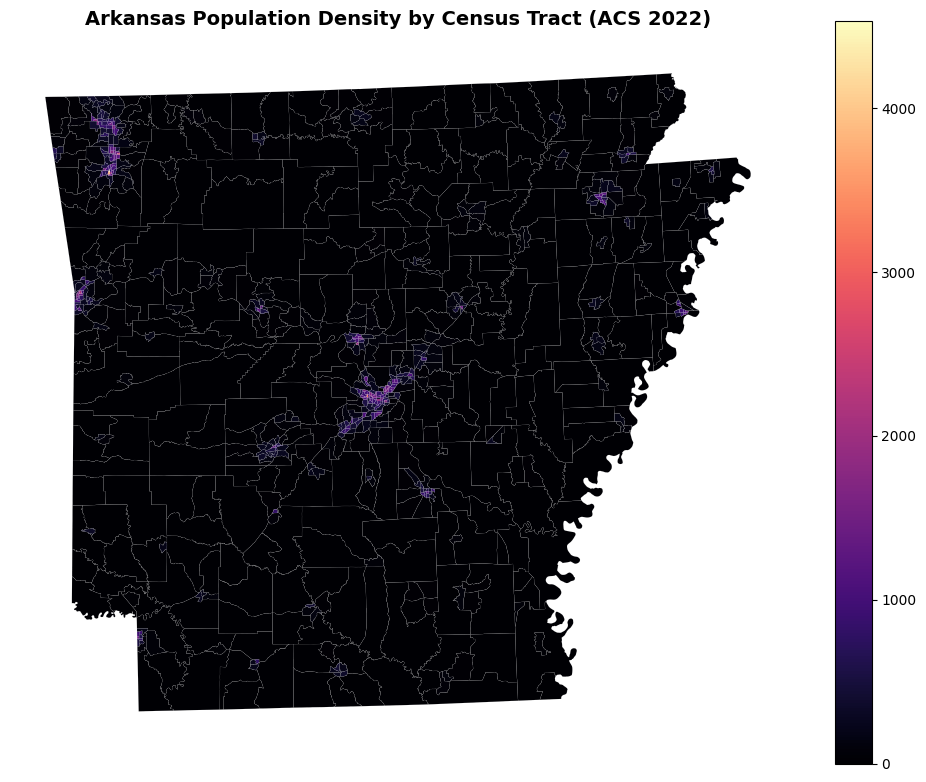

In [23]:
make_map(
    tracts_final,
    'pop_density',
    'Arkansas Population Density by Census Tract (ACS 2022)',
    cmap='magma'
)

### Map 2 — GHSL Built-up Intensity (GEE)

Google Earth Engine GHSL 2020 built-up surface intensity aggregated to census tract. 
Higher values indicate denser urban or suburban development.


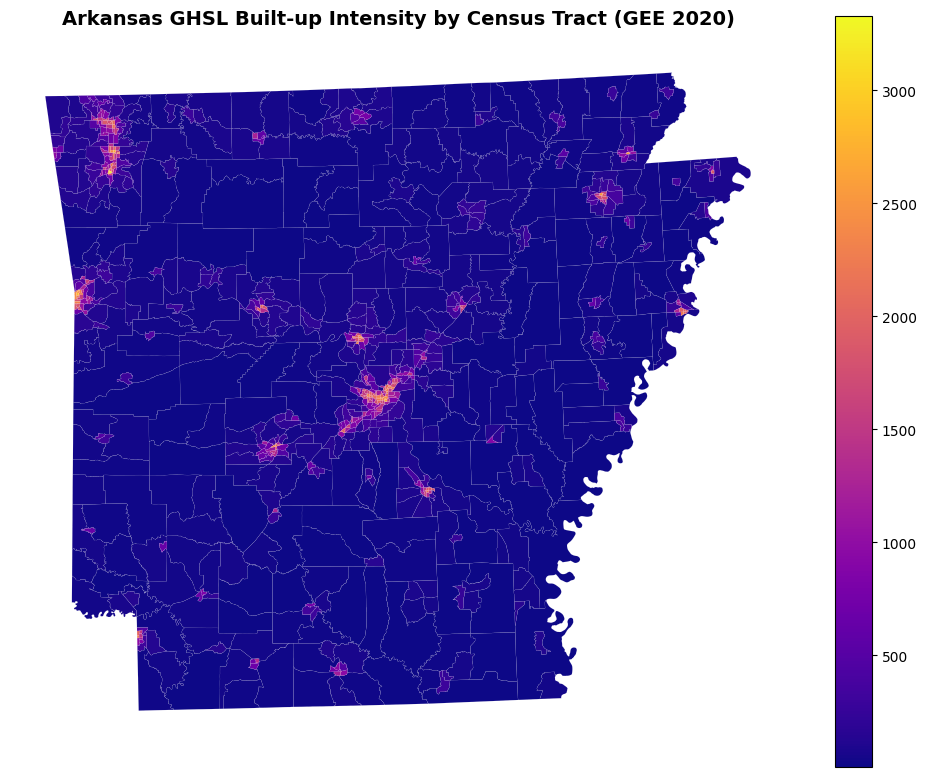

In [24]:
make_map(
    tracts_final,
    'ghsl_built_mean',
    'Arkansas GHSL Built-up Intensity by Census Tract (GEE 2020)',
    cmap='plasma'
)

### Map 3 — PM2.5 Air Quality

Annual mean PM2.5 concentrations (µg/m³) by census tract. 
Darker red-purple tones indicate higher particulate matter exposure. 
Grey tracts have no PM2.5 data in the source file.


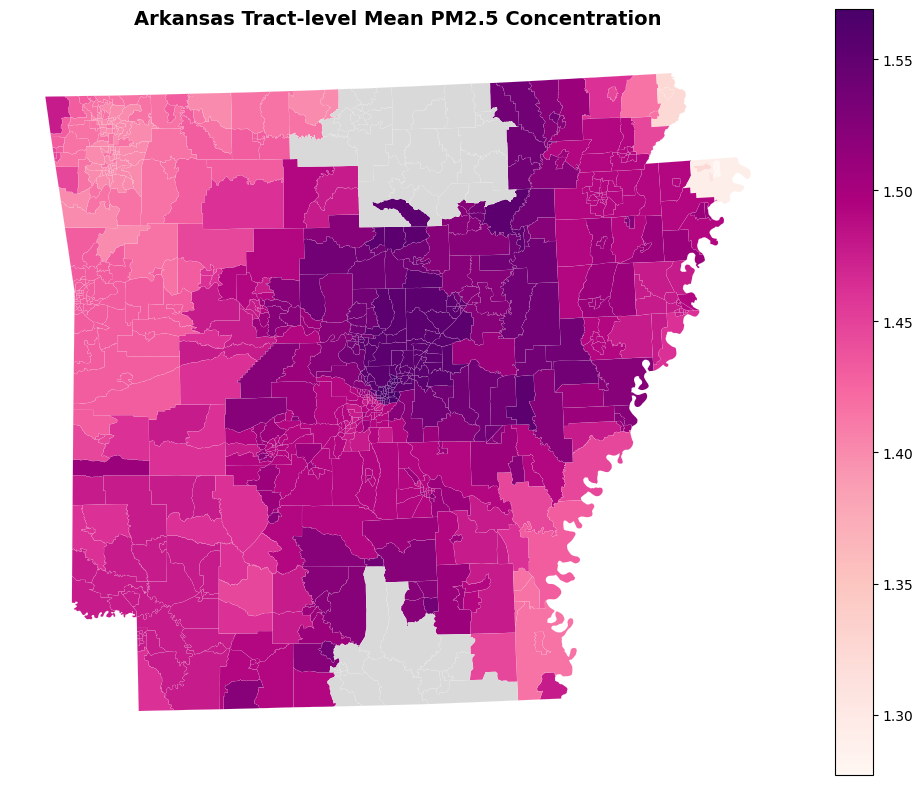

In [25]:
make_map(
    tracts_final,
    'pm25_2026_mean',
    'Arkansas Tract-level Mean PM2.5 Concentration',
    cmap='RdPu'
)

### Map 4 — Composite Environmental Risk Score (Continuous)

Equal-weighted mean of standardized population density, GHSL built-up intensity, and PM2.5. 
Green = low combined burden; red = high combined burden.


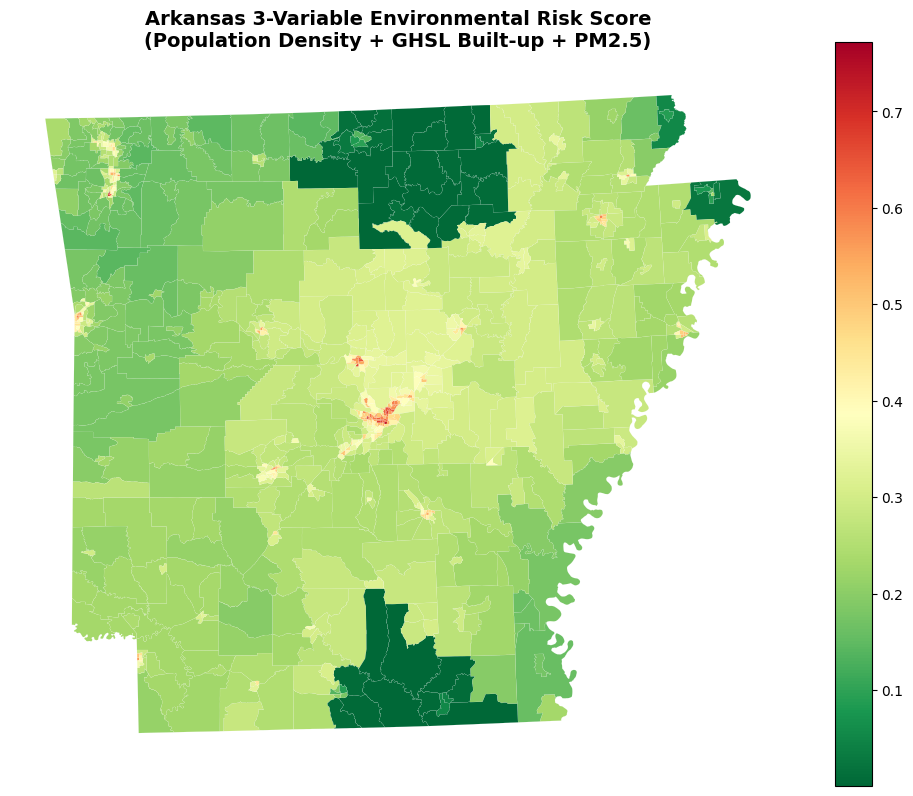

In [26]:
make_map(
    tracts_final,
    'risk_score_3var',
    'Arkansas 3-Variable Environmental Risk Score\n'
    '(Population Density + GHSL Built-up + PM2.5)',
    cmap='RdYlGn_r'
)

### Map 5 — Risk Class Map (Quintile Classification)

Tracts classified into 5 equal-count quintile risk classes. 
Green = Very Low; Crimson = Very High environmental burden overlap.


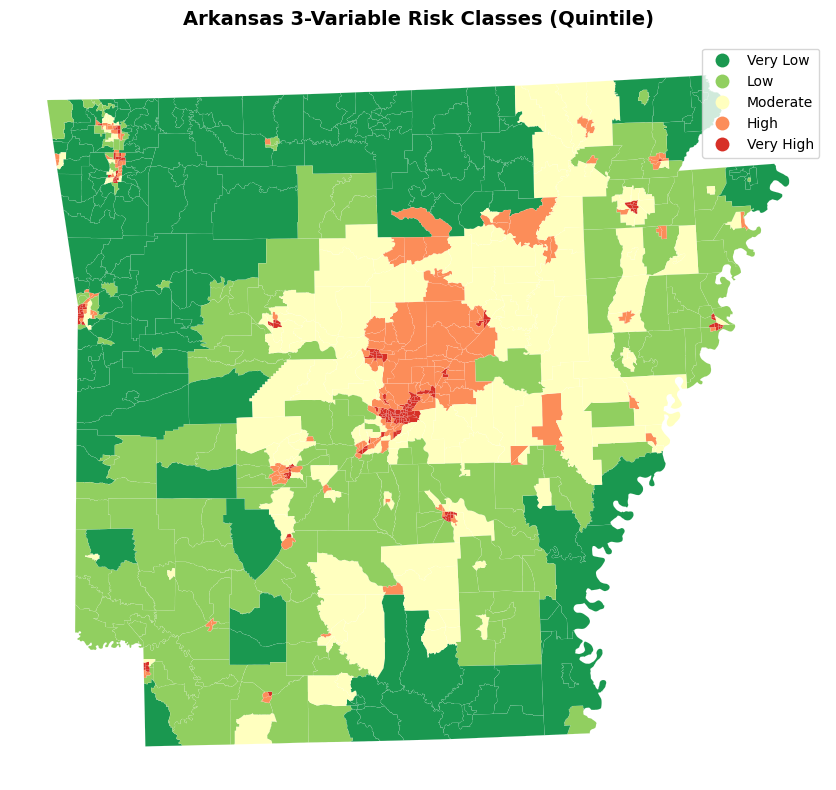

In [27]:
make_map(
    tracts_final,
    'risk_class_3var',
    'Arkansas 3-Variable Risk Classes (Quintile)',
    cmap=risk_cmap,
    categorical=True
)

### Chart 1 — Distribution of Risk Scores

Histogram showing how the composite risk score is distributed across all Arkansas census tracts. 
A roughly uniform distribution is expected when quintile classification is used.


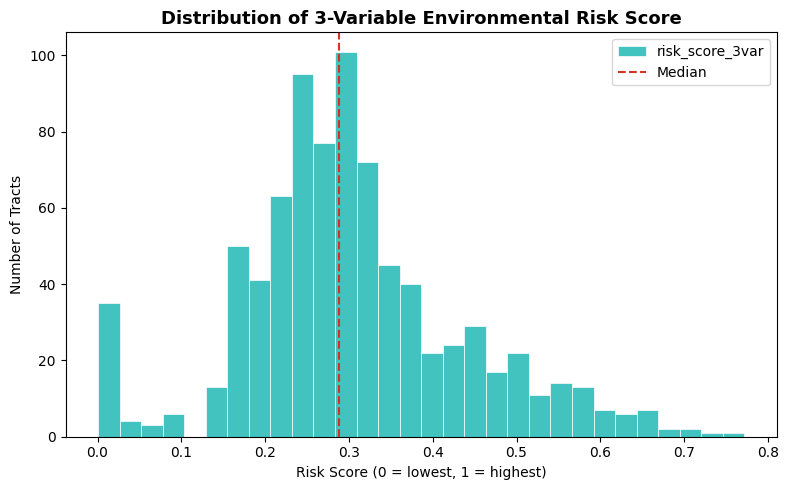

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
tracts_final['risk_score_3var'].plot.hist(
    bins=30, ax=ax,
    color="#43c3bf", edgecolor='white', linewidth=0.5
)
ax.set_title('Distribution of 3-Variable Environmental Risk Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Risk Score (0 = lowest, 1 = highest)')
ax.set_ylabel('Number of Tracts')
ax.axvline(tracts_final['risk_score_3var'].median(), color='#d73027',
           linestyle='--', linewidth=1.5, label='Median')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 2 — Population by Risk Class

Total Arkansas population living in each risk class. 
This quantifies how many residents are exposed to elevated combined environmental burden.


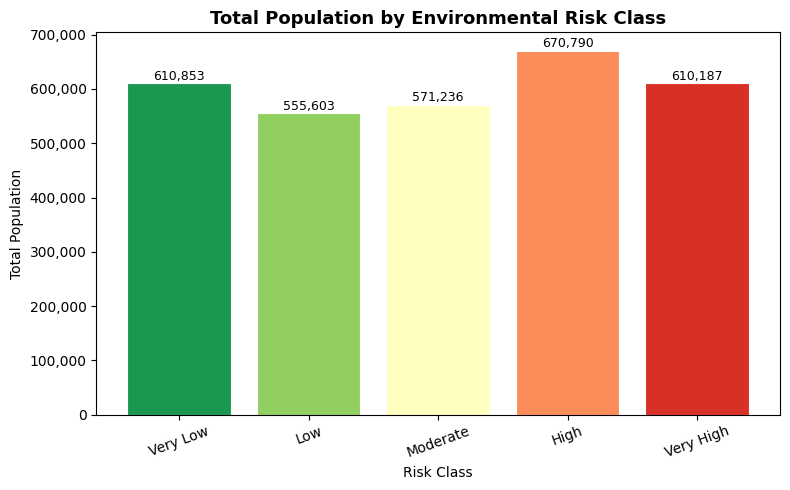

In [29]:
pop_by_class = (
    tracts_final.groupby('risk_class_3var', observed=False)['total_pop']
    .sum()
    .reindex(risk_order)
    .reset_index()
)

bar_colors = ['#1a9850', '#91cf60', '#ffffbf', '#fc8d59', '#d73027']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    pop_by_class['risk_class_3var'].astype(str),
    pop_by_class['total_pop'],
    color=bar_colors, edgecolor='white', linewidth=0.8
)
ax.set_title('Total Population by Environmental Risk Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Risk Class')
ax.set_ylabel('Total Population')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Add value labels on bars
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 500,
            f'{h:,.0f}', ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Chart 3 — Built-up Intensity vs Population Density

Each point is a census tract. Color represents PM2.5 concentration. 
Tracts in the upper-right quadrant have high density and high built-up intensity — 
the combination that most drives elevated risk scores.


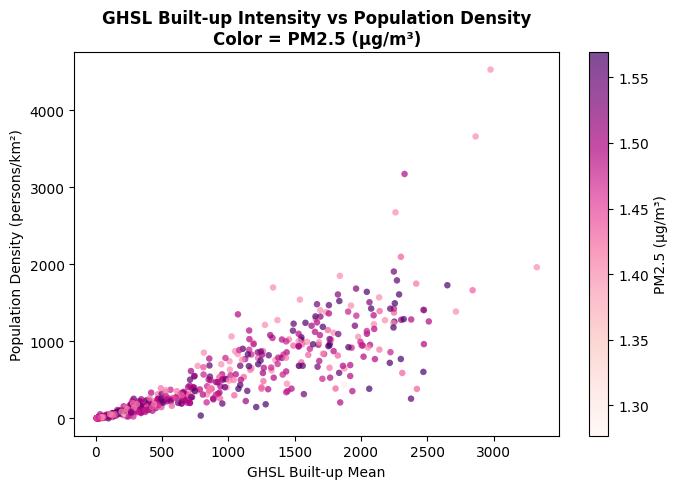

In [30]:
plot_df = tracts_final[['ghsl_built_mean', 'pop_density', 'pm25_2026_mean']].dropna()

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    plot_df['ghsl_built_mean'],
    plot_df['pop_density'],
    c=plot_df['pm25_2026_mean'],
    cmap='RdPu',
    alpha=0.7, s=22, linewidths=0
)
ax.set_title('GHSL Built-up Intensity vs Population Density\nColor = PM2.5 (µg/m³)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('GHSL Built-up Mean')
ax.set_ylabel('Population Density (persons/km²)')
cb = plt.colorbar(sc, ax=ax)
cb.set_label('PM2.5 (µg/m³)')
plt.tight_layout()
plt.show()

### Chart 4 — Average Indicator Values by Risk Class

This grouped bar chart shows the mean standardized value of each component variable per risk class. 
It reveals which indicator drives risk the most in each category.


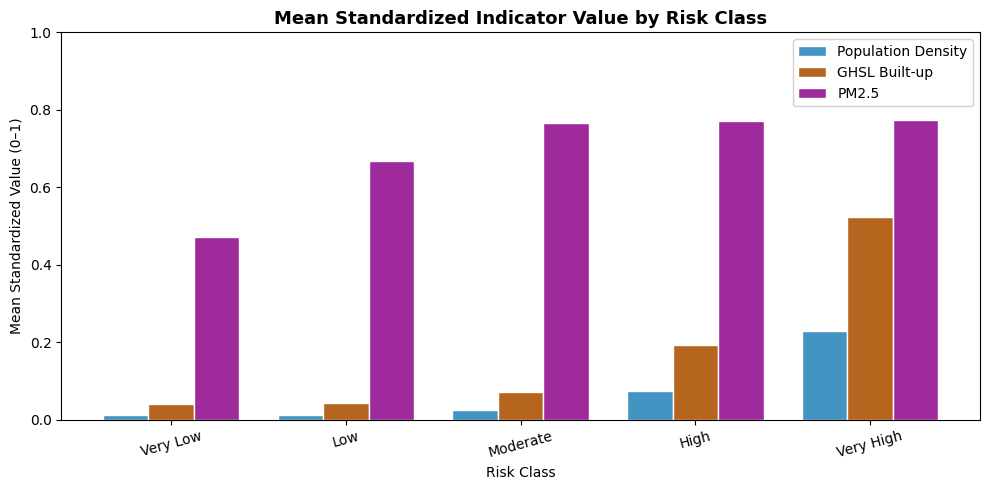

In [31]:
component_means = (
    tracts_final.groupby('risk_class_3var', observed=False)[['popden_std', 'built_std', 'pm25_std']]
    .mean()
    .reindex(risk_order)
)

x = np.arange(len(component_means.index))
width = 0.26

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, component_means['popden_std'], width,
       label='Population Density', color='#4393c3', edgecolor='white')
ax.bar(x,          component_means['built_std'],   width,
       label='GHSL Built-up',      color='#b5651d', edgecolor='white')
ax.bar(x + width,  component_means['pm25_std'],    width,
       label='PM2.5',              color='#9e2a9c', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(component_means.index.astype(str), rotation=15)
ax.set_title('Mean Standardized Indicator Value by Risk Class',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Risk Class')
ax.set_ylabel('Mean Standardized Value (0–1)')
ax.set_ylim(0, 1)
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

### Data Quality Map — Missing PM2.5 Coverage

The map below identifies tracts with missing PM2.5 values. 
The **spatial clustering** of missing tracts (rather than random distribution) suggests incomplete source-data coverage in specific areas of the state, 
rather than a statewide join error. Risk scores and PM2.5 maps should be interpreted with caution in these areas.


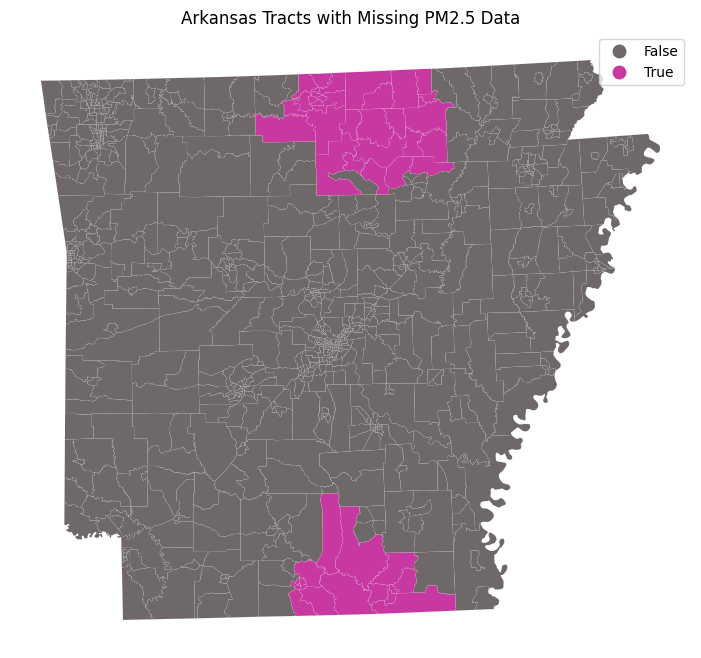

In [32]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

tracts_final["pm25_missing"] = tracts_final["pm25_2026_mean"].isna()

fig, ax = plt.subplots(figsize=(10, 8))
tracts_final.plot(
    column="pm25_missing",
    ax=ax,
    categorical=True,
    legend=True,
    cmap=ListedColormap(["#6e6868", "#c739a1"]),
    linewidth=0.05,
    edgecolor="white"
)
ax.set_title("Arkansas Tracts with Missing PM2.5 Data")
ax.set_axis_off()
plt.show()

---
<a id="section10"></a>

## 10. Discussion, Limitations & Problems Encountered

### Key Findings

The 3-variable screening model reveals that the highest-risk tracts in Arkansas are concentrated in urban cores and river-valley communities, 
where population density, built-up intensity, and PM2.5 exposure overlap most strongly. 
The equal-weighted scoring approach produces a smooth gradient across the state with clear differentiation between urban and rural tracts.

### Problems Encountered and Solutions

| Problem | Solution |
|---------|----------|
| Mismatched tract identifiers between ACS and other sources | Extracted last 11 digits of `GEOIDFQ` to create a standard GEOID |
| PM2.5 data initially available only at county or monitor level | Replaced with a tract-level EPA/CDC dataset; aggregated daily values to annual means |
| Duplicate columns after repeated notebook runs | Added a safe column-drop step before each merge |
| Redundant and disorganized code cells | Reorganized into a sequential, documented workflow |




---
<a id="section11"></a>

## 11. Conclusion & Next Steps

### Conclusion

This project successfully builds a reproducible, three-variable environmental risk screening model for Arkansas at the census tract level. 
By combining ACS population density, GHSL built-up intensity from Google Earth Engine, and EPA PM2.5 air quality data, 
the model identifies tracts where multiple environmental burdens overlap — a key concept in environmental justice analysis.

### Key Insights

- Urban cores (Little Rock metro, Fayetteville) score highest on population density and built-up intensity.
- PM2.5 variation across the state is moderate, but its combination with density and settlement pushes some peri-urban tracts into the highest risk category.
- The equal-weighted screening score is straightforward to interpret and reproduce, making it a practical starting point for agency decision-making.


### Surprises

- The spatial clustering of missing PM2.5 data was unexpected and suggests gaps in the source data for rural eastern Arkansas.
- GHSL and ACS population density are highly correlated, suggesting that built-up intensity and population density may be somewhat redundant indicators.





---
<a id="section12"></a>

## 12. Export Outputs

Final results are saved in three formats for downstream use:

- **GeoPackage (`.gpkg`)** — full spatial layer for GIS software (ArcGIS, QGIS)
- **Tract CSV** — tabular risk score results for analysis or reporting
- **County summary CSV** — county-level aggregation for executive summaries


In [33]:

tract_output = os.path.join(output_folder, "arkansas_environmental_risk_v3.gpkg")
county_output = os.path.join(output_folder, "arkansas_county_summary_v3.csv")
csv_output = os.path.join(output_folder, "arkansas_environmental_risk_v3.csv")

tracts_final.to_file(tract_output, driver="GPKG")
county_summary.to_csv(county_output, index=False)

tracts_final[[
    "GEOID",
    "total_pop",
    "area_km2",
    "pop_density",
    "ghsl_built_mean",
    "ghsl_built_sum",
    "ghsl_pop_density",
    "ghsl_pop_sum",
    "pm25_2026_mean",
    "popden_std",
    "built_std",
    "pm25_std",
    "risk_score_3var",
    "risk_class_3var"
]].to_csv(csv_output, index=False)

print("Saved tract layer to:", tract_output)
print("Saved county summary to:", county_output)
print("Saved CSV to:", csv_output)


Saved tract layer to: D:\WesternMichiganUni\GIS_Programming\FinalProject\output\arkansas_environmental_risk_v3.gpkg
Saved county summary to: D:\WesternMichiganUni\GIS_Programming\FinalProject\output\arkansas_county_summary_v3.csv
Saved CSV to: D:\WesternMichiganUni\GIS_Programming\FinalProject\output\arkansas_environmental_risk_v3.csv
